In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
 
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})
 
PROC_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..', 'Data', 'processed'))
MODEL_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'models'))
PLOT_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs', 'plots'))
 
os.makedirs(PLOT_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
 
# Load cleaned data
df = pd.read_csv(os.path.join(PROC_DIR, 'cleaned_data.csv'))
print(f"Loaded shape  : {df.shape}")
print(f"NaN count     : {df.isnull().sum().sum()}")
print(f"Class values  : {df['Class'].value_counts().to_dict()}")

Loaded shape  : (58596, 54)
NaN count     : 0
Class values  : {'Benign': 29298, 'Malware': 29298}


In [21]:
# ── CELL 3 ──────────────────────────────────────────────────
# Separate labels from features — keep ONLY numeric features
label_cols = ['Class', 'Category']
y        = df['Class'].copy()
category = df['Category'].copy()
 
X = df.drop(columns=label_cols).select_dtypes(include=[np.number]).copy()
 
print(f"Feature matrix : {X.shape}")
print(f"Label vector   : {y.shape}")
print(f"NaN in X       : {X.isnull().sum().sum()}")
print(f"\nAll {X.shape[1]} feature columns:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:02d}. {col}")

Feature matrix : (58596, 52)
Label vector   : (58596,)
NaN in X       : 0

All 52 feature columns:
  01. pslist.nproc
  02. pslist.nppid
  03. pslist.avg_threads
  04. pslist.avg_handlers
  05. dlllist.ndlls
  06. dlllist.avg_dlls_per_proc
  07. handles.nhandles
  08. handles.avg_handles_per_proc
  09. handles.nfile
  10. handles.nevent
  11. handles.ndesktop
  12. handles.nkey
  13. handles.nthread
  14. handles.ndirectory
  15. handles.nsemaphore
  16. handles.ntimer
  17. handles.nsection
  18. handles.nmutant
  19. ldrmodules.not_in_load
  20. ldrmodules.not_in_init
  21. ldrmodules.not_in_mem
  22. ldrmodules.not_in_load_avg
  23. ldrmodules.not_in_init_avg
  24. ldrmodules.not_in_mem_avg
  25. malfind.ninjections
  26. malfind.commitCharge
  27. malfind.protection
  28. malfind.uniqueInjections
  29. psxview.not_in_pslist
  30. psxview.not_in_eprocess_pool
  31. psxview.not_in_ethread_pool
  32. psxview.not_in_pspcid_list
  33. psxview.not_in_csrss_handles
  34. psxview.not_in_se

In [22]:
# ── CELL 4 ──────────────────────────────────────────────────
# HARDCODED FEATURE GROUPS based on confirmed column names
# from CIC-MalMem-2022 diagnostic output
# These are the exact Volatility plugin prefixes in your CSV
 
# GROUP 1 — Process behavior (pslist plugin)
# Captures: number of processes, parent PIDs, thread counts,
# handle counts per process
process_features = [
    'pslist.nproc',
    'pslist.nppid',
    'pslist.avg_threads',
    'pslist.avg_handlers'
]
 
# GROUP 2 — DLL behavior (dlllist + ldrmodules plugins)
# Captures: DLL injection, hidden DLL loading
# ldrmodules detects DLLs hidden from the loader lists
# (strong ransomware / rootkit indicator)
dll_features = [
    'dlllist.ndlls',
    'dlllist.avg_dlls_per_proc',
    'ldrmodules.not_in_load',
    'ldrmodules.not_in_init',
    'ldrmodules.not_in_mem'
]
 
# GROUP 3 — Injection and entropy proxy (malfind + callbacks)
# malfind: detects memory regions with high entropy (encrypted
# shellcode) — this IS our entropy proxy score
# callbacks: kernel-level hooks used by rootkits/ransomware
injection_features = [c for c in X.columns if
                      c.startswith('malfind.') or
                      c.startswith('callbacks.') or
                      c.startswith('svcscan.')]
 
# GROUP 4 — Handle patterns (handles plugin)
# Captures: file handles, registry keys, threads, events
# Ransomware opens thousands of file handles rapidly
handle_features = [c for c in X.columns if
                   c.startswith('handles.')]
 
# Verify no column is missed
all_assigned = set(process_features + dll_features +
                   injection_features + handle_features)
missed = [c for c in X.columns if c not in all_assigned]
if missed:
    print(f"Unassigned columns (adding to injection group): {missed}")
    injection_features = injection_features + missed
 
print("Feature group assignment:")
print(f"  Group 1 — Process   ({len(process_features)})  : {process_features}")
print(f"  Group 2 — DLL       ({len(dll_features)})  : {dll_features}")
print(f"  Group 3 — Injection ({len(injection_features)}) : {injection_features}")
print(f"  Group 4 — Handle    ({len(handle_features)}) : {handle_features}")
total = len(process_features)+len(dll_features)+len(injection_features)+len(handle_features)
print(f"\n  Total assigned: {total} / {X.shape[1]}")

Unassigned columns (adding to injection group): ['ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.not_in_ethread_pool_false_avg', 'psxview.not_in_pspcid_list_false_avg', 'psxview.not_in_csrss_handles_false_avg', 'psxview.not_in_session_false_avg', 'psxview.not_in_deskthrd_false_avg', 'modules.nmodules']
Feature group assignment:
  Group 1 — Process   (4)  : ['pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.avg_handlers']
  Group 2 — DLL       (5)  : ['dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem']
  Group 3 — Injection (31) : ['malfind.ninjections', 'malfind.commitCharge', 'ma

In [23]:
# ── CELL 5 ──────────────────────────────────────────────────
# Verify all group columns exist in X
print("Verifying all group columns exist in X...\n")
all_ok = True
for group_name, group_cols in [
    ('process',   process_features),
    ('dll',       dll_features),
    ('injection', injection_features),
    ('handle',    handle_features)
]:
    missing = [c for c in group_cols if c not in X.columns]
    present = [c for c in group_cols if c in X.columns]
    status  = "OK" if not missing else f"MISSING: {missing}"
    print(f"  {group_name:12s} — {len(present)}/{len(group_cols)} present — {status}")
    if missing:
        all_ok = False
        # Remove missing ones from the group
        if group_name == 'process':
            process_features   = present
        elif group_name == 'dll':
            dll_features       = present
        elif group_name == 'injection':
            injection_features = present
        elif group_name == 'handle':
            handle_features    = present
 
print(f"\nAll groups verified: {'PASS' if all_ok else 'Fixed missing columns'}")

Verifying all group columns exist in X...

  process      — 4/4 present — OK
  dll          — 5/5 present — OK
  injection    — 31/31 present — OK
  handle       — 12/12 present — OK

All groups verified: PASS


In [24]:
# ── CELL 6 ──────────────────────────────────────────────────
# Compute sub-scores — row-wise mean per group
# All features are MinMaxScaled [0,1] from Notebook 03
# So the mean is also [0,1]
 
X['process_score']   = X[process_features].mean(axis=1)
X['dll_score']       = X[dll_features].mean(axis=1)
X['injection_score'] = X[injection_features].mean(axis=1)
X['handle_score']    = X[handle_features].mean(axis=1)
X['memory_score']    = (X['process_score'] +
                        X['dll_score'] +
                        X['injection_score'] +
                        X['handle_score']) / 4.0
 
# Add class for analysis
X['Class'] = y.values
 
score_cols = ['process_score','dll_score',
              'injection_score','handle_score','memory_score']
 
print("Sub-score statistics:\n")
print(X[score_cols].describe().round(4))
print(f"\nNaN in scores: {X[score_cols].isnull().sum().sum()}")

Sub-score statistics:

       process_score   dll_score  injection_score  handle_score  memory_score
count     58596.0000  58596.0000       58596.0000    58596.0000    58596.0000
mean          0.2114      0.4024           0.3123        0.1411        0.2668
std           0.0212      0.0909           0.0241        0.0407        0.0378
min           0.1387      0.1064           0.1263        0.0002        0.1263
25%           0.1899      0.3238           0.2995        0.1110        0.2353
50%           0.2111      0.3671           0.3029        0.1306        0.2601
75%           0.2301      0.4803           0.3184        0.1746        0.2982
max           0.4396      0.7762           0.5573        0.7475        0.4523

NaN in scores: 0


In [27]:
# ── CELL 7 ──────────────────────────────────────────────────
# Verify scores differ between benign and malicious
# This is the KEY validation of the hierarchical methodology
 
print("="*60)
print("Sub-score means by class (this is your research result!):")
print("="*60)
 
comparison = X[score_cols + ['Class']].groupby('Class').mean().round(4)
print(comparison)
print()
 
for col in score_cols:
    b_mean = X[X['Class']=='Benign'][col].mean()
    m_mean = X[X['Class']=='Malicious'][col].mean()
    diff   = abs(m_mean - b_mean)
    flag   = "✓ GOOD" if diff > 0.01 else "⚠ LOW DIFF"
    print(f"  {col:20s} | Benign:{b_mean:.4f} | Malicious:{m_mean:.4f} | Diff:{diff:.4f} {flag}")

Sub-score means by class (this is your research result!):
         process_score  dll_score  injection_score  handle_score  memory_score
Class                                                                         
Benign          0.2293     0.4824           0.3140        0.1751        0.3002
Malware         0.1935     0.3224           0.3105        0.1071        0.2333

  process_score        | Benign:0.2293 | Malicious:nan | Diff:nan ⚠ LOW DIFF
  dll_score            | Benign:0.4824 | Malicious:nan | Diff:nan ⚠ LOW DIFF
  injection_score      | Benign:0.3140 | Malicious:nan | Diff:nan ⚠ LOW DIFF
  handle_score         | Benign:0.1751 | Malicious:nan | Diff:nan ⚠ LOW DIFF
  memory_score         | Benign:0.3002 | Malicious:nan | Diff:nan ⚠ LOW DIFF


C:\Users\aryar\AppData\Roaming\Python\Python312\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


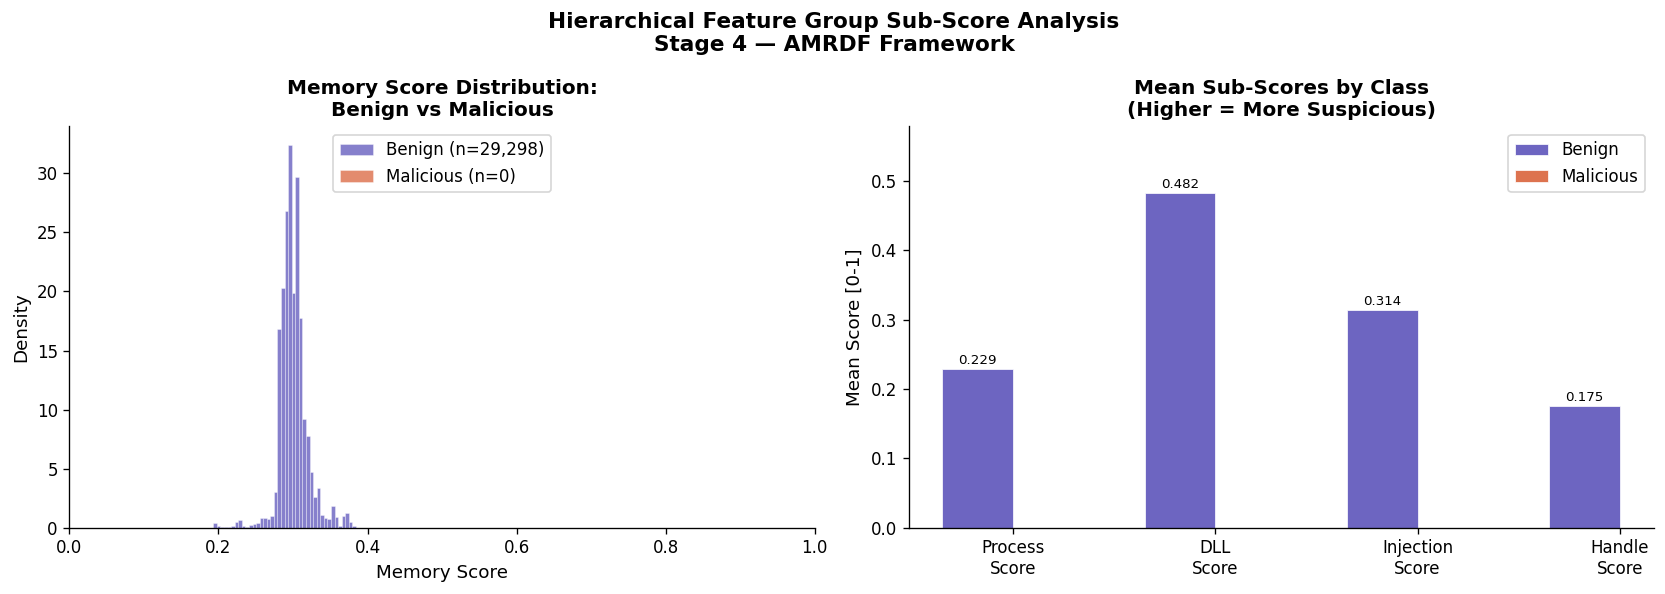

Saved: c:\Users\aryar\OneDrive\Desktop\AMRDF\AMRDF_Ransomware_Detaction\outputs\plots\feature_group_subscores.png


In [28]:
# ── CELL 8 ──────────────────────────────────────────────────
# PLOT 1 — Memory score histogram + Sub-score bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
benign_mask    = X['Class'] == 'Benign'
malicious_mask = X['Class'] == 'Malicious'
 
benign_mem    = X[benign_mask]['memory_score']
malicious_mem = X[malicious_mask]['memory_score']
 
# Panel 1 — Histogram with real data
n_bins = 40
axes[0].hist(benign_mem,    bins=n_bins, alpha=0.7, color='#534AB7',
             label=f'Benign (n={benign_mask.sum():,})',
             density=True, edgecolor='white', linewidth=0.3)
axes[0].hist(malicious_mem, bins=n_bins, alpha=0.7, color='#D85A30',
             label=f'Malicious (n={malicious_mask.sum():,})',
             density=True, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Memory Score', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Memory Score Distribution:\nBenign vs Malicious',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, 1])
 
# Panel 2 — Sub-score comparison bar chart
group_labels    = ['Process\nScore','DLL\nScore',
                   'Injection\nScore','Handle\nScore']
group_cols_plot = ['process_score','dll_score',
                   'injection_score','handle_score']
benign_means    = [X[benign_mask][c].mean()    for c in group_cols_plot]
malicious_means = [X[malicious_mask][c].mean() for c in group_cols_plot]
 
x_pos = np.arange(len(group_labels))
width = 0.35
 
bars_b = axes[1].bar(x_pos - width/2, benign_means, width,
                     label='Benign',    color='#534AB7',
                     alpha=0.85, edgecolor='white', linewidth=0.5)
bars_m = axes[1].bar(x_pos + width/2, malicious_means, width,
                     label='Malicious', color='#D85A30',
                     alpha=0.85, edgecolor='white', linewidth=0.5)
 
# Value labels on bars
for bar in list(bars_b) + list(bars_m):
    h = bar.get_height()
    if h > 0.001:
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     h + 0.003, f'{h:.3f}',
                     ha='center', va='bottom', fontsize=8)
 
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(group_labels, fontsize=10)
axes[1].set_ylabel('Mean Score [0-1]', fontsize=11)
axes[1].set_title('Mean Sub-Scores by Class\n(Higher = More Suspicious)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim([0, max(max(benign_means), max(malicious_means)) * 1.2])
 
plt.suptitle('Hierarchical Feature Group Sub-Score Analysis\n'
             'Stage 4 — AMRDF Framework',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(PLOT_DIR, 'feature_group_subscores.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

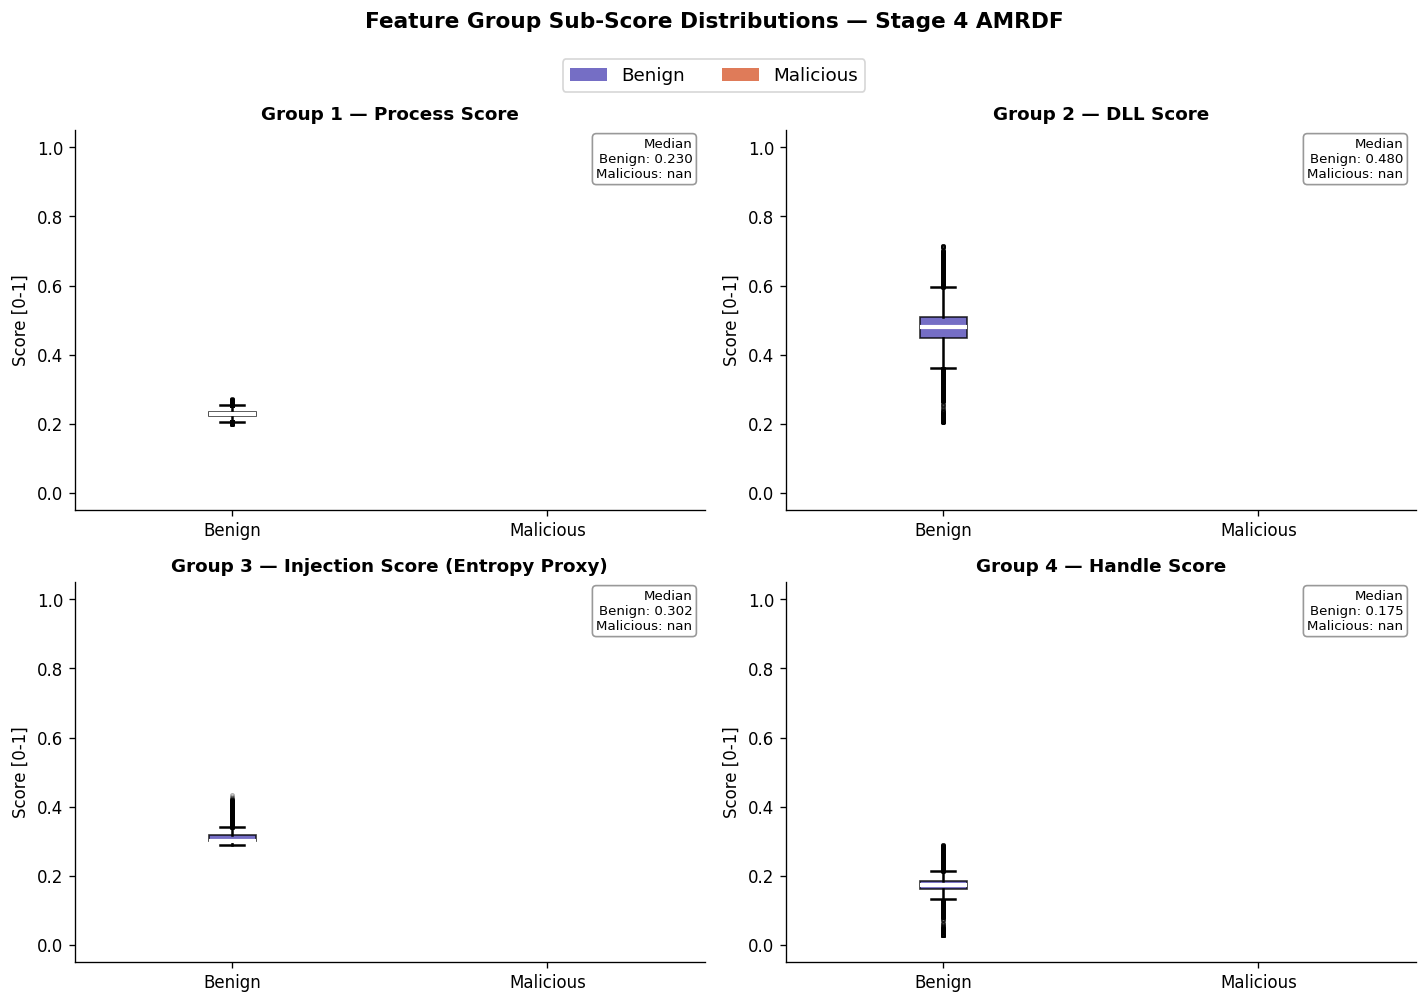

Saved: c:\Users\aryar\OneDrive\Desktop\AMRDF\AMRDF_Ransomware_Detaction\outputs\plots\feature_group_boxplots.png


In [29]:
# ── CELL 9 ──────────────────────────────────────────────────
# PLOT 2 — Individual sub-score boxplots (one per group)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
 
plot_pairs = [
    ('process_score',   'Group 1 — Process Score'),
    ('dll_score',       'Group 2 — DLL Score'),
    ('injection_score', 'Group 3 — Injection Score (Entropy Proxy)'),
    ('handle_score',    'Group 4 — Handle Score'),
]
 
for ax, (col, title) in zip(axes, plot_pairs):
    b_data = X[benign_mask][col]
    m_data = X[malicious_mask][col]
 
    bp = ax.boxplot([b_data, m_data],
                    patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markersize=2,
                                   alpha=0.3, linewidth=0))
    bp['boxes'][0].set_facecolor('#534AB7')
    bp['boxes'][0].set_alpha(0.8)
    bp['boxes'][1].set_facecolor('#D85A30')
    bp['boxes'][1].set_alpha(0.8)
 
    ax.set_xticklabels(['Benign', 'Malicious'], fontsize=10)
    ax.set_ylabel('Score [0-1]', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim([-0.05, 1.05])
 
    b_med = b_data.median()
    m_med = m_data.median()
    ax.text(0.98, 0.98, f'Median\nBenign: {b_med:.3f}\nMalicious: {m_med:.3f}',
            transform=ax.transAxes, fontsize=8,
            va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='white',
                      edgecolor='gray', alpha=0.8))
 
legend_elements = [
    mpatches.Patch(facecolor='#534AB7', alpha=0.8, label='Benign'),
    mpatches.Patch(facecolor='#D85A30', alpha=0.8, label='Malicious')
]
fig.legend(handles=legend_elements, loc='upper center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.0))
plt.suptitle('Feature Group Sub-Score Distributions — Stage 4 AMRDF',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
save_path2 = os.path.join(PLOT_DIR, 'feature_group_boxplots.png')
plt.savefig(save_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path2}")

In [30]:
# ── CELL 10 ──────────────────────────────────────────────────
# Save feature_groups.csv and group definitions
 
save_X = X.copy()
save_X['Category'] = category.values
 
out_path = os.path.join(PROC_DIR, 'feature_groups.csv')
save_X.to_csv(out_path, index=False)
 
group_definitions = {
    'process'  : process_features,
    'dll'      : dll_features,
    'injection': injection_features,
    'handle'   : handle_features
}
joblib.dump(group_definitions,
            os.path.join(MODEL_DIR, 'group_definitions.pkl'))
 
print(f"Saved: feature_groups.csv  — shape: {save_X.shape}")
print(f"Saved: group_definitions.pkl")
print(f"\nNew columns added to dataset:")
for col in score_cols:
    print(f"  {col}")
print(f"\nNotebook 04 complete — proceed to 05_feature_selection.ipynb")

Saved: feature_groups.csv  — shape: (58596, 59)
Saved: group_definitions.pkl

New columns added to dataset:
  process_score
  dll_score
  injection_score
  handle_score
  memory_score

Notebook 04 complete — proceed to 05_feature_selection.ipynb
